# FloodNet NYC Tutorial
Author: Mark Bauer

# Table of Contents

# Summary
This notebook generates and visualizes flood profiles from FloodNet sensor data. It first covers how to interpret raw flood depth values, then builds a set of reusable plotting functions to visualize individual and overlaid flood profiles. It analyzes rate of onset and drainage by timing how quickly events cross a depth threshold, interpolating between readings for sub-sample precision. Finally, it identifies notable flood events by grouping sensor readings around storm windows to compare timing and severity across sensors.

1. **Generating Flood Profiles**
   - 1.1 Interpreting Flood Depth Values
   - 1.2 Visualizing Flood Profiles
   - 1.3 Rate of Onset and Drainage Flood Profiles
   - 1.4 Notable Flood Events

# Import Libraries

In [1]:
# libraries
# Standard library
import json
from pathlib import Path

# Third-party
import duckdb
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

# %load_ext autoreload
%reload_ext autoreload

# custom flood profile plotting functions
import floodnet

In [2]:
# print versions of packages for reproducibility
libraries = {
    "polars": pl.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "duckdb": duckdb.__version__,
}

for name, version in libraries.items():
    print(f"{name:10s} {version}")

polars     1.38.1
numpy      2.4.2
pandas     3.0.5
duckdb     1.4.4


In [3]:
# sanity check Manifest file
manifest = json.loads(Path("data/manifest.json").read_text())["datasets"]
print(json.dumps(manifest, indent=2))

[
  {
    "dataset_id": "kb2e-tjy3",
    "name": "FloodNet: Sensor Deployment Metadata",
    "data_updated": "2026-09-01",
    "metadata_updated": null,
    "view_count": 1315,
    "download_count": 1288,
    "comment_count": 0,
    "average_rating": 0,
    "category": "Environment",
    "tags": [
      "unclassified"
    ],
    "update_frequency": "unknown",
    "row_count": 491,
    "column_count": 16,
    "data_url": "https://data.cityofnewyork.us/resource/kb2e-tjy3.csv",
    "downloaded_at": "2026-09-07",
    "last_checked_at": "2026-09-07",
    "latest_created_at": "2026-09-01T13:00:19.833Z",
    "previous_created_at": null
  },
  {
    "dataset_id": "aq7i-eu5q",
    "name": "FloodNet: Street Flooding Events Measured by FloodNet Sensors",
    "data_updated": "2026-09-01",
    "metadata_updated": null,
    "view_count": 3392,
    "download_count": 1430,
    "comment_count": 0,
    "average_rating": 0,
    "category": "Environment",
    "tags": [
      "unclassified"
    ],
    "upd

Note: The manifest captures dataset metadata at the time of download. Since NYC Open Data datasets are updated periodically, results may differ over time. For the latest version, review the dataset page on NYC Open Data or rerun the data download notebook.

In [4]:
# list files in data directory
%ls data

Flood Events_Data Dictionary.xlsx
Floodnet_Open_Data_-_Data_Description_03.05.2026.pdf
boroughs.parquet
flood-events.csv
manifest.json
sensor-metadata.csv


To review how we downloaded these datasets from NYC Open Data, please refer to the previous notebook [00-download-data.ipynb](https://github.com/mebauer/floodnet-nyc-tutorial/blob/main/00-download-data.ipynb).

# Prep Work
## Load and Inspect Data

For a more extensive approach to inspecting the data, please refer to notebook [01-load-inspect.ipynb](https://github.com/mebauer/floodnet-nyc-tutorial/blob/main/01-load-inspect.ipynb).

In [5]:
# 1) read in flood sensor deployments as dataframe
metadata_path = "data/sensor-metadata.csv"
metadata_df = pl.read_csv(metadata_path, try_parse_dates=True)

# inspect the shape of the data
n_rows, n_columns = metadata_df.shape
print("Metadata shape:")
print(f"Number of rows: {n_rows}")
print(f"Number of columns: {n_columns}")

# 2) read in flood events as dataframe
events_path = "data/flood-events.csv"
events_df = pl.read_csv(
    events_path,
    # some columns have sparce data, need to expand the row count
    infer_schema_length=100000,
    try_parse_dates=True
)

# inspect the shape of the data
n_rows, n_columns = events_df.shape

print("\nFlood Events shape:")
print(f"Number of rows: {n_rows:,}")
print(f"Number of columns: {n_columns}")

Metadata shape:
Number of rows: 491
Number of columns: 16

Flood Events shape:
Number of rows: 3,184
Number of columns: 13


## Join Sensor Metadata and Flood Events Datasets

In [6]:
# merge flood sensor events with sensor metadata
merged_df = events_df.join(
    metadata_df,
    # join key is sensor_id, but sensor_name is included in both datasets
    on=["sensor_id", "sensor_name"],
    how="left",  # keep all events, even if metadata is missing
)

# inspect the shape of the merged data
n_rows, n_columns = merged_df.shape
print(f"Number of rows of merged df: {n_rows:,}")
print(f"Number of columns: {n_columns}")

# events without matching metadata
missing_meta_count = merged_df["sensor_id"].null_count()
print(f"Events without matching sensor metadata: {missing_meta_count}\n")

# preview the first few rows
merged_df.head()

Number of rows of merged df: 3,184
Number of columns: 27
Events without matching sensor metadata: 0



sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs,date_installed,tidally_influenced,date_removed,street_name,borough,zipcode,community_board,council_district,census_tract,nta,latitude,longitude,lowest_point_height_delta_inches,location
str,str,datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,str,str,datetime[μs],str,datetime[μs],str,str,i64,i64,str,i64,str,f64,f64,f64,str
"""Q - Beach 84 St""","""Q-beach-84-st-0me680""",2023-10-30 12:00:39,2023-10-30 16:38:19,17.72,133.86,143.81,277.66,211.41,103.6,0.0,"""[0.00, 0.87, 1.02, 1.38, 1.93,…","""[0, 1008, 1134, 1512, 1826, 20…",2021-12-10 00:00:00,"""Yes""",null,"""Beach 84th Street""","""Queens""",11693,414,"""QN14""",4094202,"""QN1402""",40.59136,-73.80996,8.27,"""POINT (-73.80996 40.59136)"""
"""BX - 1st St/Avenue A""","""BX-1st-st-avenue-a-1zby90""",2025-04-26 23:17:20,2025-04-27 11:55:34,6.18,27.95,730.29,758.24,132.81,0.0,0.0,"""[0.00, 0.71, 1.38, 1.38, 1.38,…","""[0, 64, 129, 132, 196, 260, 32…",2024-07-18 00:00:00,"""No""",null,"""Avenue A""","""Bronx""",10474,202,"""BX02""",2011702,"""BX0201""",40.812851,-73.881043,3.62,"""POINT (-73.881043 40.812851)"""
"""Q - Beach 35 St/Beach Channel …","""Q-beach-35-st-beach-channel-dr…",2024-02-09 11:41:01,2024-02-09 13:20:57,5.31,54.51,45.43,99.94,45.09,0.0,0.0,"""[0.00, 0.43, 0.63, 0.71, 0.94,…","""[0, 68, 136, 204, 273, 341, 40…",2023-12-19 00:00:00,"""Yes""",null,"""Beach 35th Street""","""Queens""",11691,414,"""QN14""",4099200,"""QN1401""",40.596618,-73.767808,6.97,"""POINT (-73.767808 40.596618)"""
"""BX - Tibbett Ave/W 234th St""","""BX-w-234th-st-tibbett-ave-2cak…",2025-08-20 21:05:19,2025-08-21 00:46:19,1.18,80.0,141.0,221.0,0.0,0.0,0.0,"""[0.00, 0.43, 0.47, 0.47, 0.51,…","""[0, 60, 120, 180, 240, 300, 36…",2025-03-27 00:00:00,"""No""",null,"""Tibbett Avenue""","""Bronx""",10463,208,"""BX08""",2028700,"""BX0802""",40.88326,-73.90585,4.09,"""POINT (-73.90585 40.88326)"""
"""Q - Davenport Ct 1""","""Q-davenport-ct-1-07zks0""",2024-01-10 00:39:25,2024-01-10 02:30:40,2.09,59.82,51.43,111.25,0.0,0.0,0.0,"""[0.00, 0.47, 0.47, 0.43, 0.43,…","""[0, 63, 127, 189, 252, 315, 37…",2021-03-05 00:00:00,"""Yes""",null,"""Davenport Court""","""Queens""",11414,410,"""QN10""",4088400,"""QN1003""",40.653387,-73.830559,6.97,"""POINT (-73.830559 40.653387)"""


## Data Cleaning
Converting datetimes to local New York City.

In [7]:
merged_df = (
    merged_df.with_columns(
        
        # assign timezone to UTC
        pl.col("flood_start_time").dt.replace_time_zone("UTC"),
        pl.col("flood_end_time").dt.replace_time_zone("UTC"),
        pl.col("date_installed").dt.replace_time_zone("UTC"),
        pl.col("date_removed").dt.replace_time_zone("UTC"),

        # convert UTC to NYC local time
        pl.col("flood_start_time")
            .dt.convert_time_zone("America/New_York")
            .alias("flood_start_time_et"),
        pl.col("flood_end_time")
            .dt.convert_time_zone("America/New_York")
            .alias("flood_end_time_et")
    )
)

# preview datetime conversion
dt_cols = [
    "flood_start_time", "flood_end_time",
    "flood_start_time_et", "flood_end_time_et"
]
merged_df.select(dt_cols).head()

flood_start_time,flood_end_time,flood_start_time_et,flood_end_time_et
"datetime[μs, UTC]","datetime[μs, UTC]","datetime[μs, America/New_York]","datetime[μs, America/New_York]"
2023-10-30 12:00:39 UTC,2023-10-30 16:38:19 UTC,2023-10-30 08:00:39 EDT,2023-10-30 12:38:19 EDT
2025-04-26 23:17:20 UTC,2025-04-27 11:55:34 UTC,2025-04-26 19:17:20 EDT,2025-04-27 07:55:34 EDT
2024-02-09 11:41:01 UTC,2024-02-09 13:20:57 UTC,2024-02-09 06:41:01 EST,2024-02-09 08:20:57 EST
2025-08-20 21:05:19 UTC,2025-08-21 00:46:19 UTC,2025-08-20 17:05:19 EDT,2025-08-20 20:46:19 EDT
2024-01-10 00:39:25 UTC,2024-01-10 02:30:40 UTC,2024-01-09 19:39:25 EST,2024-01-09 21:30:40 EST


In the example below, the FloodNet dataset is read in as a CSV file, so nested values (e.g. values inside lists) appear as a string column datatype. Transform the columns to list datatype.

In [8]:
# before column transformation
merged_df.select(["flood_profile_time_secs", "flood_profile_depth_inches"]).head()

flood_profile_time_secs,flood_profile_depth_inches
str,str
"""[0, 1008, 1134, 1512, 1826, 20…","""[0.00, 0.87, 1.02, 1.38, 1.93,…"
"""[0, 64, 129, 132, 196, 260, 32…","""[0.00, 0.71, 1.38, 1.38, 1.38,…"
"""[0, 68, 136, 204, 273, 341, 40…","""[0.00, 0.43, 0.63, 0.71, 0.94,…"
"""[0, 60, 120, 180, 240, 300, 36…","""[0.00, 0.43, 0.47, 0.47, 0.51,…"
"""[0, 63, 127, 189, 252, 315, 37…","""[0.00, 0.47, 0.47, 0.43, 0.43,…"


In [9]:
# convert string column to list column type
merged_df = merged_df.with_columns(
    # overwrite column names
    pl.col("flood_profile_time_secs").str.json_decode(pl.List(pl.Float64)),
    pl.col("flood_profile_depth_inches").str.json_decode(pl.List(pl.Float64))
)

# preview column type converstion
merged_df.select(["flood_profile_time_secs", "flood_profile_depth_inches"]).head()

flood_profile_time_secs,flood_profile_depth_inches
list[f64],list[f64]
"[0.0, 1008.0, … 16660.0]","[0.0, 0.87, … 0.0]"
"[0.0, 64.0, … 45494.0]","[0.0, 0.71, … 0.0]"
"[0.0, 68.0, … 5996.0]","[0.0, 0.43, … 0.0]"
"[0.0, 60.0, … 13260.0]","[0.0, 0.43, … 0.0]"
"[0.0, 63.0, … 6675.0]","[0.0, 0.47, … 0.0]"


In [10]:
# inspect all column data types
merged_df.schema

Schema([('sensor_name', String),
        ('sensor_id', String),
        ('flood_start_time', Datetime(time_unit='us', time_zone='UTC')),
        ('flood_end_time', Datetime(time_unit='us', time_zone='UTC')),
        ('max_depth_inches', Float64),
        ('onset_time_mins', Float64),
        ('drain_time_mins', Float64),
        ('duration_mins', Float64),
        ('duration_above_4_inches_mins', Float64),
        ('duration_above_12_inches_mins', Float64),
        ('duration_above_24_inches_mins', Float64),
        ('flood_profile_depth_inches', List(Float64)),
        ('flood_profile_time_secs', List(Float64)),
        ('date_installed', Datetime(time_unit='us', time_zone='UTC')),
        ('tidally_influenced', String),
        ('date_removed', Datetime(time_unit='us', time_zone='UTC')),
        ('street_name', String),
        ('borough', String),
        ('zipcode', Int64),
        ('community_board', Int64),
        ('council_district', String),
        ('census_tract', Int64),
  

# Generating Flood Profiles

## Interpreting Flood Depth Values
This section examines the structure of flood depth values, as well as their relationship with time.

In [11]:
# preview timeseries flood profile columns
ts_cols = [
    "flood_profile_time_secs",
    "flood_profile_depth_inches"
]

merged_df.select(ts_cols).head()

flood_profile_time_secs,flood_profile_depth_inches
list[f64],list[f64]
"[0.0, 1008.0, … 16660.0]","[0.0, 0.87, … 0.0]"
"[0.0, 64.0, … 45494.0]","[0.0, 0.71, … 0.0]"
"[0.0, 68.0, … 5996.0]","[0.0, 0.43, … 0.0]"
"[0.0, 60.0, … 13260.0]","[0.0, 0.43, … 0.0]"
"[0.0, 63.0, … 6675.0]","[0.0, 0.47, … 0.0]"


Each element inside the time in seconds column (i.e. flood_profile_time_secs) maps directly to a flood depth element in the depth inches column (i.e. flood_profile_depth_inches). For simplicity, let's examine **one flood event**.

A single row represents a sequence of time (offset from zero) and depth (mm) pairs recorded during the flood event for a given sensor.

In [12]:
# get the first row (e.g. one flood event)
depths_row = merged_df.get_column("flood_profile_depth_inches").item(0)

# number of sensor readings
print(f"Total flood depth elements in our example row: {len(depths_row)}")

Total flood depth elements in our example row: 58


In [13]:
# preview first five depths in our example event
depths_row.head(5)

""
f64
0.0
0.87
1.02
1.38
1.93


In [14]:
# preview last five depths
depths_row.tail(5)

""
f64
3.66
3.15
2.87
0.59
0.0


The first and last depth elements should both be zero.

Let's transform this example to a dataframe to have access to dataframe methods. Note: we're still examing our sample flood event.

In [15]:
time_col = "flood_profile_time_secs"
depth_col = "flood_profile_depth_inches"

# explode lists within our single flood event into a two-column df
depths_df = pl.DataFrame({
    time_col: merged_df.get_column(time_col).item(0),
    depth_col: merged_df.get_column(depth_col).item(0)
})

depths_df

flood_profile_time_secs,flood_profile_depth_inches
f64,f64
0.0,0.0
1008.0,0.87
1134.0,1.02
1512.0,1.38
1826.0,1.93
…,…
15526.0,3.66
15715.0,3.15
15777.0,2.87


If you explode and unravel one flood event from the dataset, it would look like the example above. This data structure is much easier to visualize. We've also added column names to explicitly inform the user what these values are.

Let's examine statistics of this sensor for this flood event.

In [16]:
seconds_total = depths_df.get_column('flood_profile_time_secs').max()
depth_max = depths_df.get_column('flood_profile_depth_inches').max()

print(f"This sensor recorded a flood event of approximately {seconds_total / 3600:,.2f} hours and a max flood depth of {depth_max:.2f} inches.")

This sensor recorded a flood event of approximately 4.63 hours and a max flood depth of 17.72 inches.


Finally, let's examine the time intervals of the sensor's readings for this flood event.

In [17]:
# Sensor reading intervals
intervals = (
    depths_df.select(
        pl.col("flood_profile_time_secs").diff().alias("interval"))
    .get_column("interval")
    .drop_nulls()
    .cast(pl.Int64)
)

shortest = intervals.min()
longest = intervals.max()

print(f"Shortest interval: {shortest:,} seconds")
print(f"Longest interval: {longest:,} seconds")

Shortest interval: 8 seconds
Longest interval: 1,008 seconds


## Visualizing Flood Profiles
Now that you've seen how flood depth values are structured, and how to inspect them, it's time to generate flood profiles. Below you'll find a series of functions that let you visualize flood profiles.

In [18]:
# Visualize the flood profile for the highest depth event
max_depth_df = merged_df.sort(by='max_depth_inches', descending=True).head(1)

max_depth_df

sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs,date_installed,tidally_influenced,date_removed,street_name,borough,zipcode,community_board,council_district,census_tract,nta,latitude,longitude,lowest_point_height_delta_inches,location,flood_start_time_et,flood_end_time_et
str,str,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,list[f64],list[f64],"datetime[μs, UTC]",str,"datetime[μs, UTC]",str,str,i64,i64,str,i64,str,f64,f64,f64,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]"
"""Q - 183rd St/90th Ave""","""Q-183rd-st-90th-ave-1lmow0""",2026-05-20 23:21:49 UTC,2026-05-21 00:35:49 UTC,46.14,26.98,47.01,74.0,56.79,49.79,37.31,"[0.0, 3.39, … 0.0]","[0.0, 59.0, … 4440.0]",2023-10-26 00:00:00 UTC,"""No""",null,"""90th Avenue""","""Queens""",11423,412,"""QN12""",4047000,"""QN1201""",40.711128,-73.777904,9.49,"""POINT (-73.777904 40.711128)""",2026-05-20 19:21:49 EDT,2026-05-20 20:35:49 EDT


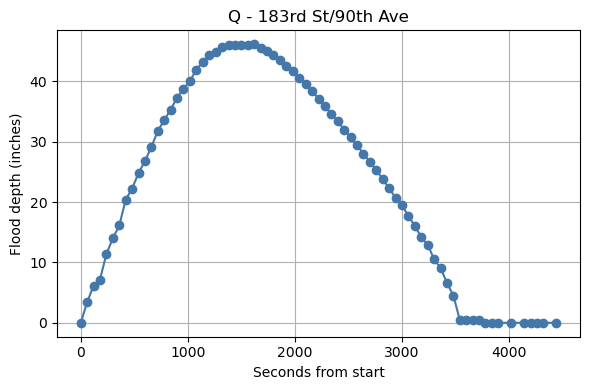

In [19]:
# Retrieve sensor_id and sensor name
sensor_id = max_depth_df.get_column('sensor_id').item(0)
title = max_depth_df.get_column('sensor_name').item(0)

# Plot flood profile
fig, ax = floodnet.plot_sensor_profiles(max_depth_df, sensor_id)

ax.set_title(title)
plt.tight_layout()

Additionally, you can view all the flood events of a sensor.

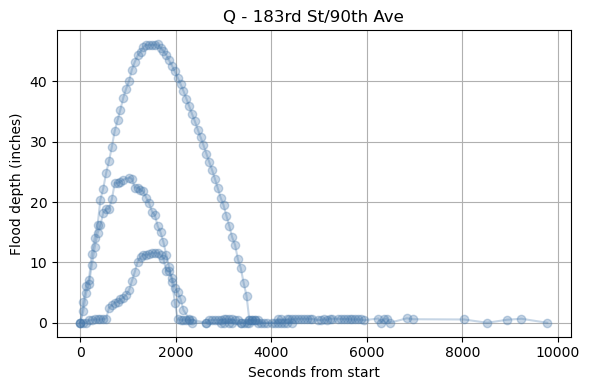

In [20]:
# Retrieve sensor name and id
sensor_name = max_depth_df.get_column('sensor_name').item(0)
top_event_df = merged_df.filter(pl.col('sensor_name') == sensor_name)

# Retrieve sensor_id
sensor_id = top_event_df.get_column('sensor_id').item(0)

fig, ax = floodnet.plot_sensor_profiles(top_event_df, sensor_id, alpha=.3)

ax.set_title(top_event_df['sensor_name'][0])
plt.tight_layout()

Finally, you can examine multiple flood profiles.

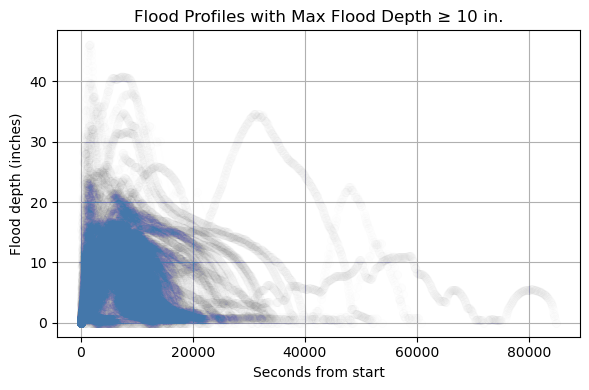

In [21]:
# Filter df to only events with >= 10in max flood depth
filtered_df = merged_df.filter(pl.col('max_depth_inches') >= 10)

fig, ax = floodnet.plot_sensor_profiles(filtered_df, alpha=.002)

ax.set_title('Flood Profiles with Max Flood Depth ≥ 10 in.')
plt.tight_layout()

The plotting function above is used to inspect flood events, flood depth, and flood duration. Because everything is normalized to ***seconds from start***, it's an easy way to compare flood profiles.

Next, we'll display the x-axis as a real date and time. The plotting method below only accepts one flood event because it has to create one x-axis. Note: For events that occoured during the same storm (i.e. a shared x-axis), that plotting function is further below in the notebook.

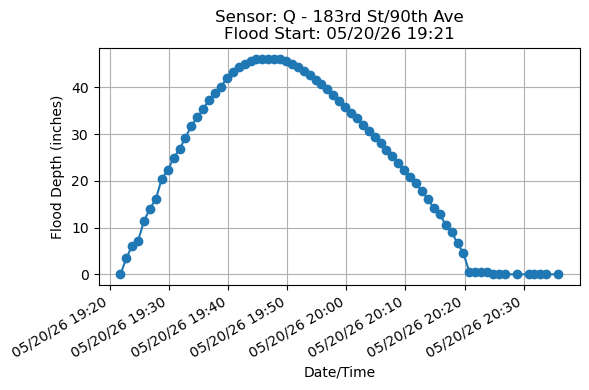

In [22]:
# Locate the top depth event
top_max_depth = (
    merged_df.sort(pl.col('max_depth_inches'), descending=True)
    .head(1)
)

# Assign variables
sensor_name = "sensor_name"
flood_start = "flood_start_time_et"

fig, ax = floodnet.plot_flood_event(top_max_depth, sensor_name, flood_start)

plt.tight_layout()

## Quickest Time to Threshold
We have a function that creates a new dataframe with statistics related to time to threshold. Below, you'll observe events ranked by fastest time to 12 inches.

In [23]:
# Top 5 fastest time to 12 inches
profiles = floodnet.time_to_threshold(df=merged_df, threshold_inches=12)

profiles.head()

name,depth_max_inches,start,end,threshold_inches,time_to_thresh_sec,time_to_thresh_minutes,rate_to_thresh_in_per_min,x_values,y_values
str,f64,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",i32,f64,f64,f64,list[f64],list[f64]
"""M - Rivington St/Suffolk St""",18.5,2026-06-11 21:59:21 EDT,2026-06-11 23:29:21 EDT,12,123.29,2.05,5.84,"[0.0, 180.0, … 5400.0]","[0.0, 17.52, … 0.0]"
"""BK - Carroll St/4th Av""",31.3,2022-09-13 04:35:09 EDT,2022-09-13 05:21:25 EDT,12,136.93,2.28,5.26,"[0.0, 63.0, … 2777.0]","[0.0, 3.46, … 0.0]"
"""BK - Carroll St/4th Av""",28.15,2026-08-23 06:45:24 EDT,2026-08-23 07:25:24 EDT,12,151.51,2.53,4.75,"[0.0, 60.0, … 2400.0]","[0.0, 3.03, … 0.0]"
"""BK - Carroll St/4th Av""",35.94,2023-09-29 07:53:39 EDT,2023-09-29 10:02:50 EDT,12,175.25,2.92,4.11,"[0.0, 63.0, … 7751.0]","[0.0, 1.22, … 0.0]"
"""Q - 204th St/ 100th Ave""",32.72,2026-05-20 19:27:49 EDT,2026-05-20 20:32:48 EDT,12,175.7,2.93,4.1,"[0.0, 60.0, … 3900.0]","[0.0, 5.71, … 0.0]"


In [24]:
# Control top N rows with top_n parameter
profiles = floodnet.time_to_threshold(df=merged_df, threshold_inches=12, top_n=3)

profiles

name,depth_max_inches,start,end,threshold_inches,time_to_thresh_sec,time_to_thresh_minutes,rate_to_thresh_in_per_min,x_values,y_values
str,f64,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",i32,f64,f64,f64,list[f64],list[f64]
"""M - Rivington St/Suffolk St""",18.5,2026-06-11 21:59:21 EDT,2026-06-11 23:29:21 EDT,12,123.29,2.05,5.84,"[0.0, 180.0, … 5400.0]","[0.0, 17.52, … 0.0]"
"""BK - Carroll St/4th Av""",31.3,2022-09-13 04:35:09 EDT,2022-09-13 05:21:25 EDT,12,136.93,2.28,5.26,"[0.0, 63.0, … 2777.0]","[0.0, 3.46, … 0.0]"
"""BK - Carroll St/4th Av""",28.15,2026-08-23 06:45:24 EDT,2026-08-23 07:25:24 EDT,12,151.51,2.53,4.75,"[0.0, 60.0, … 2400.0]","[0.0, 3.03, … 0.0]"


We can create figures against our time to threshold dataframe.

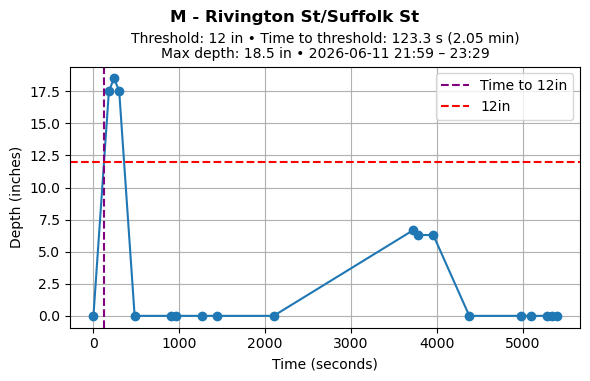

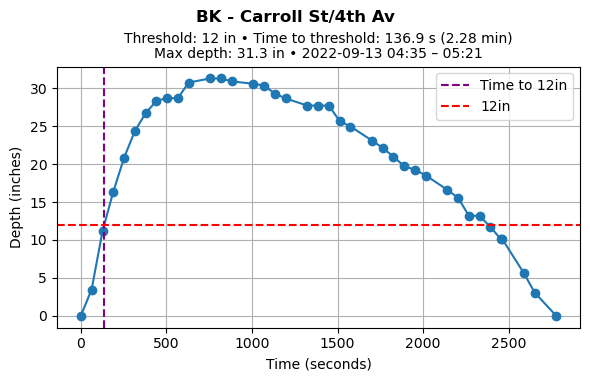

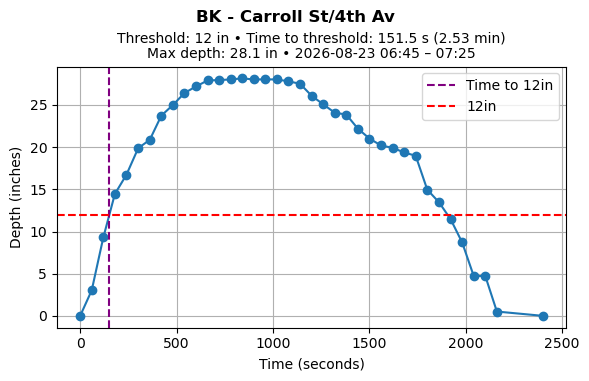

In [25]:
# Plot time to threshold
figs = floodnet.plot_threshold_crossings(profiles)
plt.tight_layout()

# Notable Flood Events
A function to plot these notable events. However, you probably want to customize your plot's aesthetics. If you prefer full control, copy the plotting block and customize the aesthetics directly.

## December 2022 Winter Storm Elliott

In [26]:
# The same events the plot below draws, one row per flood event
date_storm = '2022-12-23'
time_buffer = 12
storm_name = 'Winter Storm Elliott'

events_table = floodnet.storm_events(
    merged_df,
    date_storm, time_buffer, storm_name
)

sensors_flooded = events_table['sensor_id'].n_unique()
print(f"{storm_name}: {sensors_flooded} sensors flooded across {events_table.height} flood events")

# every column of the input carries through; preview a few
cols = [
    'storm_name',
    'window_start',
    'window_end',
    'sensor_name',
    'borough',
    'flood_start_time_et',
    'max_depth_inches'
]

events_table.select(cols).head()

Winter Storm Elliott: 7 sensors flooded across 7 flood events


storm_name,window_start,window_end,sensor_name,borough,flood_start_time_et,max_depth_inches
str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",str,str,"datetime[μs, America/New_York]",f64
"""Winter Storm Elliott""",2022-12-22 12:00:00 EST,2022-12-24 12:00:00 EST,"""BK - Hoyt St/5th St""","""Brooklyn""",2022-12-23 03:51:52 EST,4.69
"""Winter Storm Elliott""",2022-12-22 12:00:00 EST,2022-12-24 12:00:00 EST,"""BK - 9th St/Smith St""","""Brooklyn""",2022-12-23 04:07:29 EST,5.59
"""Winter Storm Elliott""",2022-12-22 12:00:00 EST,2022-12-24 12:00:00 EST,"""Q - Beach 84 St""","""Queens""",2022-12-23 05:00:52 EST,38.19
"""Winter Storm Elliott""",2022-12-22 12:00:00 EST,2022-12-24 12:00:00 EST,"""Q - Russell St 1""","""Queens""",2022-12-23 05:10:48 EST,31.34
"""Winter Storm Elliott""",2022-12-22 12:00:00 EST,2022-12-24 12:00:00 EST,"""Q - Russell St 2""","""Queens""",2022-12-23 05:12:13 EST,31.77


In [27]:
# how many sensors flooded, and where
# n_unique, not len: one sensor can log several events in a single storm
events_table.group_by(['storm_name', 'borough']).agg(
    pl.col('sensor_id').n_unique().alias('sensors_flooded'),
    pl.len().alias('flood_events')
).sort('sensors_flooded', descending=True)

storm_name,borough,sensors_flooded,flood_events
str,str,u32,u32
"""Winter Storm Elliott""","""Queens""",5,5
"""Winter Storm Elliott""","""Brooklyn""",2,2


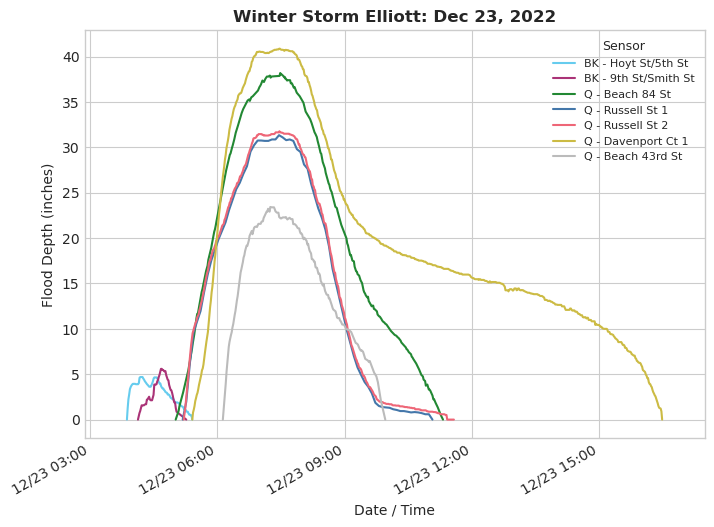

In [28]:
date_storm = '2022-12-23'
time_buffer = 12
storm_name = 'Winter Storm Elliott'

fig, ax = floodnet.plot_storm_events(merged_df, date_storm, time_buffer, storm_name)

## Tropical Storm Henri

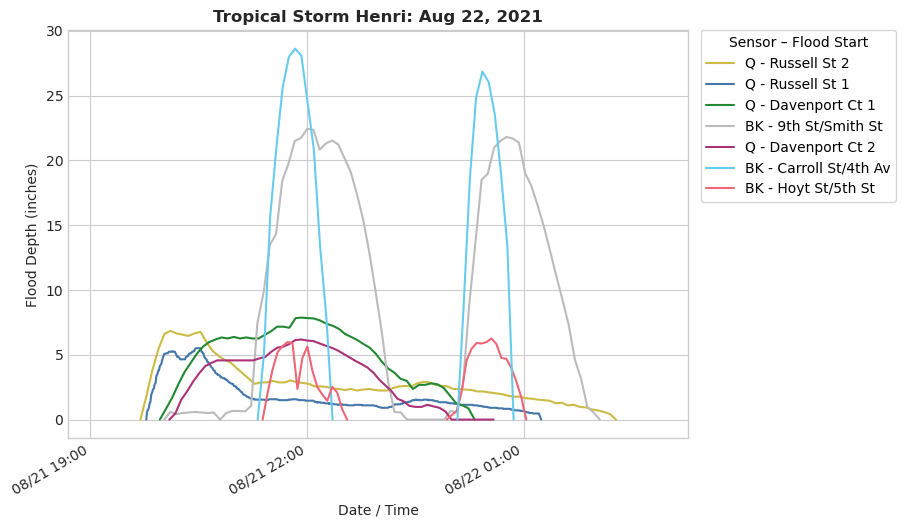

In [29]:
date_storm = '2021-08-22'
time_buffer = 6
storm_name = 'Tropical Storm Henri'

fig, ax = floodnet.plot_storm_events(merged_df, date_storm, time_buffer, storm_name)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles,
    labels,
    title="Sensor – Flood Start",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    ncol=1,
    borderaxespad=0.0,
)

## Tropical Storm Ophelia

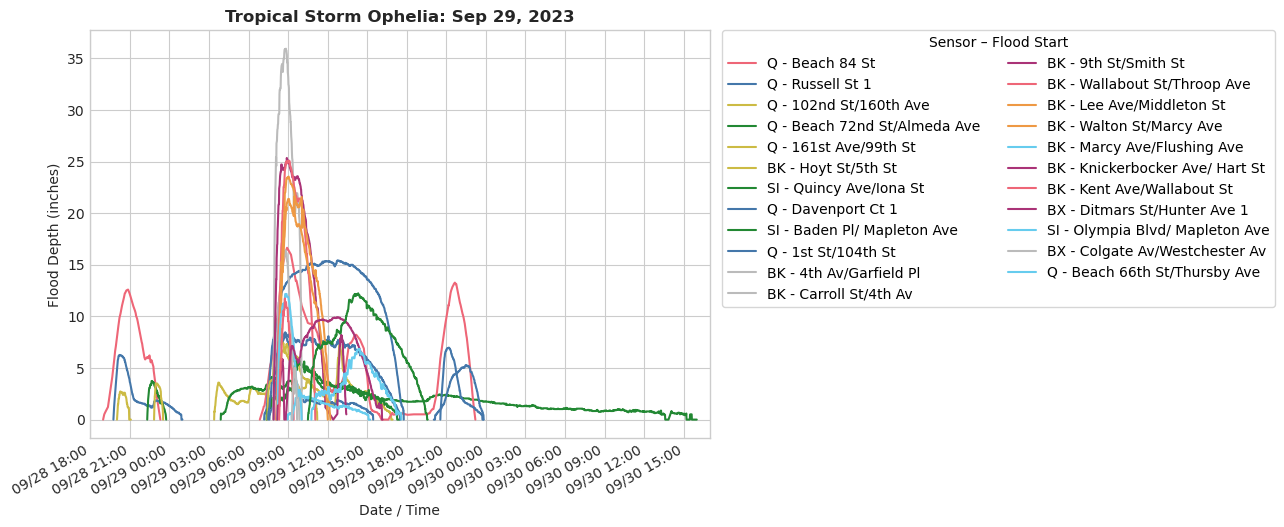

In [30]:
date_range = '2023-09-29'
time_buffer = 6
storm_name = 'Tropical Storm Ophelia'

fig, ax = floodnet.plot_storm_events(merged_df, date_range, time_buffer, storm_name)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles,
    labels,
    title="Sensor – Flood Start",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    ncol=2,
    borderaxespad=0.0,
)

## Hurricane Ida

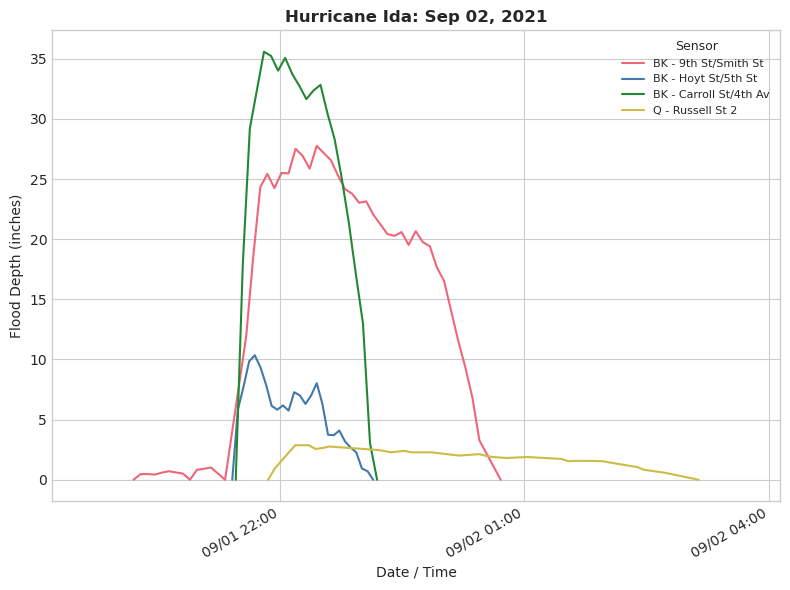

In [31]:
date_storm = '2021-09-02'
time_buffer = 6
storm_name = 'Hurricane Ida'

fig, ax = floodnet.plot_storm_events(merged_df, date_storm, time_buffer, storm_name)

plt.tight_layout()

## October 25, 2025 Winter Storm

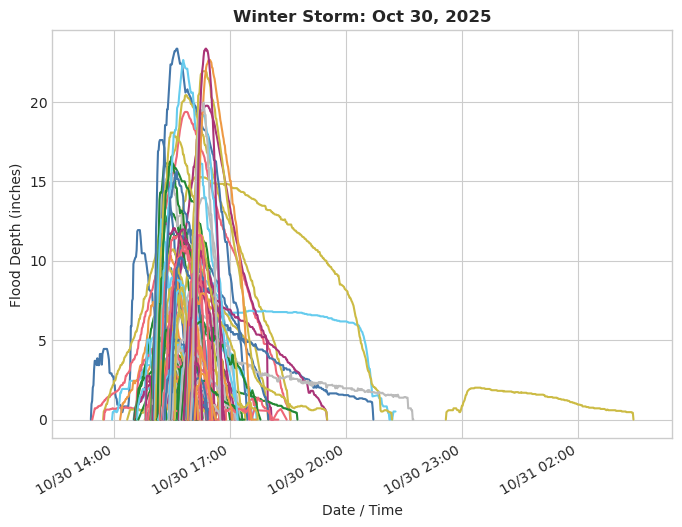

In [32]:
date_storm = '2025-10-30'
time_buffer = 0
storm_name = 'Winter Storm'

fig, ax = floodnet.plot_storm_events(merged_df, date_storm, time_buffer, storm_name)

ax.legend().set_visible(False)  

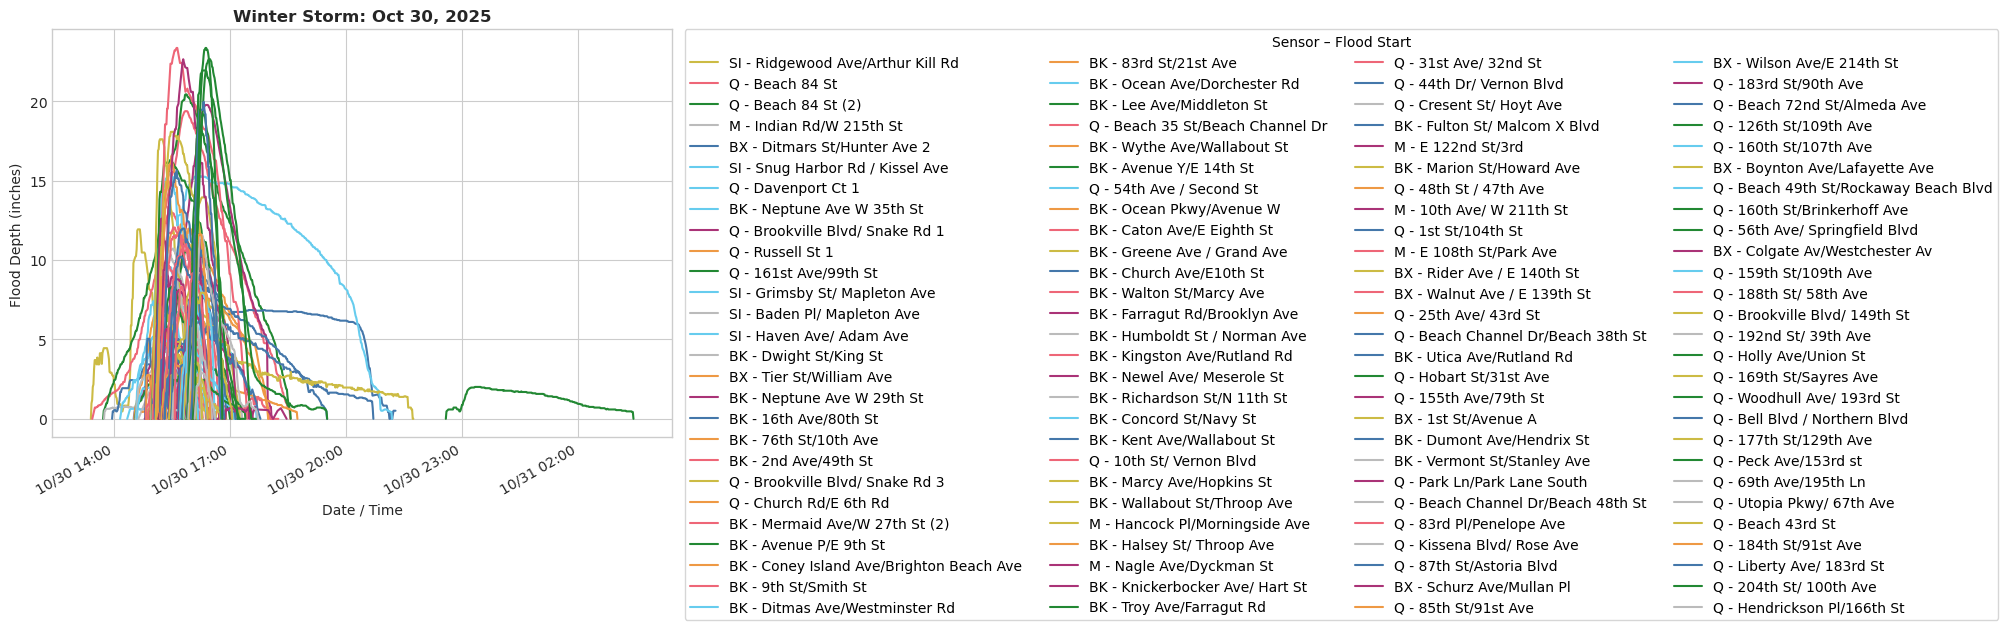

In [33]:
date_storm = '2025-10-30'
time_buffer = 1
storm_name = 'Winter Storm'

fig, ax = floodnet.plot_storm_events(merged_df, date_storm, time_buffer, storm_name)

handles, labels = ax.get_legend_handles_labels()

# expand and reformat the legend
ax.legend(
    handles,
    labels,
    title="Sensor – Flood Start",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    ncol=4,
    borderaxespad=0.0,
)